<a href="https://colab.research.google.com/github/sp-mujuni/1-Year-MachineLearning-Journey/blob/master/clustering_run_2_DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geospatial Data and Computational  Intelligence Lab

## Clustering the lab's air quality dataset

**2. DBSCAN**

## 1. Importing libraries

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import os

## 2. Listing files in dataset



In [2]:
# For Google Colab - mount Google Drive if not already mounted
from google.colab import drive  # type: ignore
drive.mount('/content/drive')
# Update this path to match where your Clustering folder is in Google Drive
dataset_path = '/content/drive/MyDrive/2025/AI/Clustering/clean'
print(f"Using Colab path: {dataset_path}")

print(f"Files in dataset: {os.listdir(dataset_path)}")

Mounted at /content/drive
Using Colab path: /content/drive/MyDrive/2025/AI/Clustering/clean
Files in dataset: ['fantasto_codetect_db_fixed.csv']


## 3. Loading dataset

In [3]:
df = pd.read_csv(f'{dataset_path}/fantasto_codetect_db_fixed.csv')

## 4. Selecting pollutant columns for clustering

In [4]:
features = ['carbondioxide', 'carbonmonoxide', 'dust']
X = df[features].copy()

## 5. Handling missing values

In [5]:
X = X.fillna(X.mean())

## 6. Scaling the data

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 7. Running DBSCAN

In [7]:
dbscan = DBSCAN(
    eps=0.5,           # neighborhood size
    min_samples=5      # minimum number of points to form a cluster
)
labels = dbscan.fit_predict(X_scaled)

## 9. Adding cluster labels to dataframe

In [8]:
df['dbscan_cluster'] = labels

## 9. Visualizing clusters

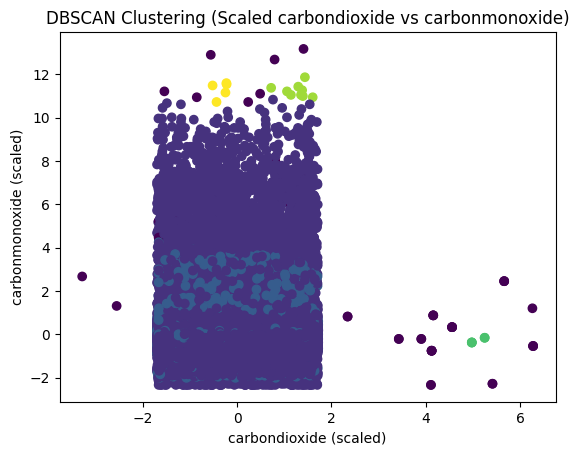

In [9]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("DBSCAN Clustering (Scaled carbondioxide vs carbonmonoxide)")
plt.xlabel("carbondioxide (scaled)")
plt.ylabel("carbonmonoxide (scaled)")
plt.show()

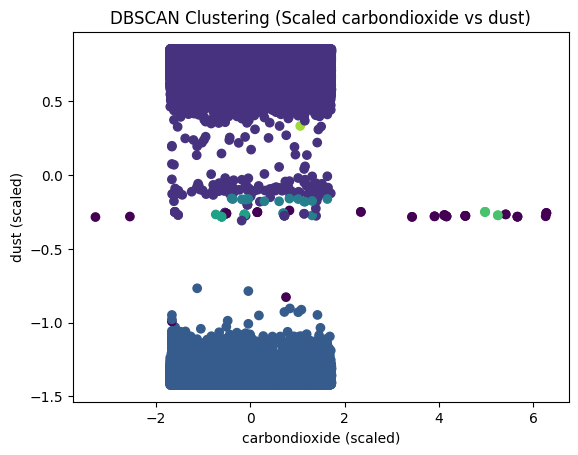

In [10]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 2], c=labels)
plt.title("DBSCAN Clustering (Scaled carbondioxide vs dust)")
plt.xlabel("carbondioxide (scaled)")
plt.ylabel("dust (scaled)")
plt.show()

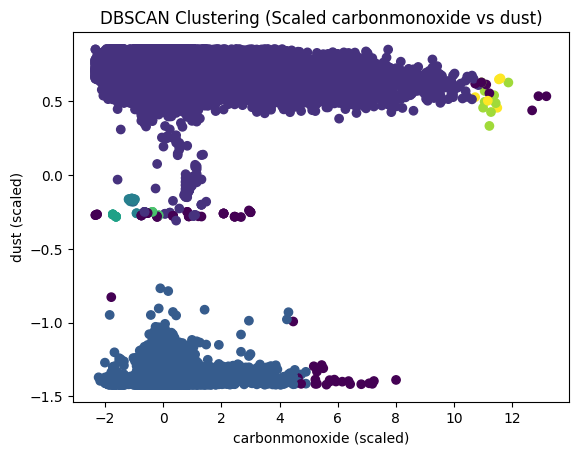

In [11]:
plt.scatter(X_scaled[:, 1], X_scaled[:, 2], c=labels)
plt.title("DBSCAN Clustering (Scaled carbonmonoxide vs dust)")
plt.xlabel("carbonmonoxide (scaled)")
plt.ylabel("dust (scaled)")
plt.show()

## 10. Counting cluster outputs

In [12]:
print(df['dbscan_cluster'].value_counts())

dbscan_cluster
 0    68300
 1    36832
-1       69
 2       17
 3        9
 5        9
 4        5
 6        5
Name: count, dtype: int64


## 11 .Analyzing Cluster Outputs


In [13]:
df.groupby("dbscan_cluster")[['carbondioxide','carbonmonoxide','dust']].mean()

,carbondioxide,carbonmonoxide,dust
dbscan_cluster,,,
-1,1006.434783,106.753623,-7937.130435
0,649.324963,42.999473,29265.380249
1,648.200831,42.420015,-30914.062853
2,763.705882,23.647059,2842.764706
3,565.111111,11.888889,284.555556
4,1693.400000,37.600000,711.800000
5,908.555556,249.555556,22767.444444
6,580.800000,250.600000,24231.800000
